# **External Ballistics and Ray Propagation**
## A Numerically Stable Trajectory Engine for Nonlinear ODE Systems

**Author:** Vanya Videva  
**Course:** Math Concepts for Developers 

**Date:** March 2026

---

## 1. Introduction

#### **What is External Ballistics?**
External ballistics is the study of a projectile's motion **after** it leaves the barrel — subject to gravity, aerodynamic drag, and atmospheric conditions. 
The mathematical foundation dates back to Newton's laws of motion, and today it is essential in applications ranging from sport shooting to game development.

The simplest model treats the projectile as a **point mass** moving through the air, described by a system of nonlinear ordinary differential equations (ODEs).

#### **Connection to Ray Propagation**
A ray of light traveling through a medium with a varying refractive index follows a curved path — described by the **same mathematical structure** as a ballistic trajectory. Both systems are nonlinear ODE problems, making them ideal for demonstrating a unified numerical engine.

#### **Motivation**
The choice of numerical integrator has a significant impact on simulation accuracy. 
A poorly chosen method leads to:
- **Energy drift** — the simulation gains or loses energy artificially
- **Numerical instability** — small errors grow exponentially over time

This project explores and compares three integrators to demonstrate these effects.

#### **Objectives**
1. Implement a trajectory engine in **Python** using NumPy and Matplotlib
2. Model two physical systems: **ballistics with drag** and **ray in gradient medium**
3. Compare three numerical integrators: **Explicit Euler, Symplectic Euler, RK4**
4. Analyze **numerical stability** and **energy conservation** across methods
5. Visualize trajectory, energy error, and stability as a function of time step $\Delta t$



**Keywords:** External ballistics, Trajectory simulation, Numerical methods, ODE systems, Numerical stability, Ray propagation, Runge-Kutta, Symplectic Euler

## 2. Mathematical Framework

#### **What is an ODE System?**

An **Ordinary Differential Equation (ODE)** describes how a quantity changes over time. For a moving projectile, tracking two quantities:

- **Position** — where is the projectile? $(x, y)$
- **Velocity** — how fast and in which direction? $(v_x, v_y)$

The state of the system at any time $t$ is described by a vector:

$$\mathbf{s} = (x, y, v_x, v_y)$$

The ODE system describes how this state evolves over time:

$$\frac{d\mathbf{s}}{dt} = f(\mathbf{s}, t)$$

In plain words: *"the rate of change of the state equals some function 
of the current state"*

#### **Connection to Derivatives**

As shown by Darakchiev (2026), instantaneous velocity is defined as the limit of the difference quotient (the ratio of change in position to change in time) as $\Delta t \to 0$:

$$v(t) = \lim_{\Delta t \to 0} \frac{s(t + \Delta t) - s(t)}{\Delta t}$$

This means velocity is the **first derivative** of position, and acceleration is the **first derivative** of velocity:

$$v_x = \frac{dx}{dt}, \quad v_y = \frac{dy}{dt}$$

$$a_x = \frac{dv_x}{dt}, \quad a_y = \frac{dv_y}{dt}$$

This gives complete ODE system:

$$\frac{dx}{dt} = v_x, \quad \frac{dy}{dt} = v_y$$

$$\frac{dv_x}{dt} = a_x, \quad \frac{dv_y}{dt} = a_y$$

Where $a_x$ and $a_y$ are accelerations caused by the forces acting on the projectile — which will be defined in the next section.

## 3. Forces Acting on the Projectile

#### **Gravity**

The simplest force acting on the projectile is gravity - a constant downward acceleration:

$$a_x^{gravity} = 0, \quad a_y^{gravity} = -g$$

Where $g = 9.81 \, m/s^2$ is the gravitational acceleration. 
It acts only in the vertical direction - no horizontal component.

#### **Aerodynamic Drag**

In reality, the proejctile also experiences air resistance. The drag force acts opposite to the velocity direction and is proportional to the square of the speed:

$$F_{drag} = \frac{1}{2} \rho C_d A v^2$$

Where:
- $\rho$ - air density ($1.225 \, kg/m^3$ at sea level)
- $C_d$ - drag coefficient, depends on the projectile shape
- $A$ - cross-sectional area of the projectile
- $v = \sqrt{v_x^2 + v_y^2}$ - speed (magnitude of velocity)

This is called **quadratic drag** - the faster the projectile, the stronger the resistance.

#### **Total Acceleration**

Combining both forces using Newton's second law $F = ma$, rearranged to $a = F/m$:

$$a_x = -\frac{F_{drag}}{m} \cdot \frac{v_x}{v}$$

$$a_y = -g - \frac{F_{drag}}{m} \cdot \frac{v_y}{v}$$

The $\frac{v_x}{v}$ and $\frac{v_y}{v}$ terms give the direction of the drag - always opposite to the direction of motion. This completes the ODE system.

#### **Ray Propagation - A Different Kind of Force**

For a light ray traveling through a medium with varying refractive index $n(x, y)$, there is no gravity or drag, but the ray still bends. The ray curves toward regions of higher refractive index, described by:

$$\frac{d^2\mathbf{r}}{dt^2} = \nabla n(\mathbf{r})$$

Where $\nabla n$ is the gradient of the refractive index (Darakchiev, 2026) — pointing in the direction of greatest change.

This is mathematically identical in structure to the ballistics ODE system - just with different physical forces. A unified numerical engine can therefore simulate both systems with the same code.


## 4. Numerical Integration Methods

The ODE systems derived in the previous sections generally do not have simple analytical solutions once nonlinear forces such as quadratic drag are included. Instead, the trajectory must be approximated numerically by evaluating the derivatives over small time steps.

A numerical integrator advances the system state forward in time using the relation 

$$\mathbf{s}_{n+1} = \mathbf{s}_n + \Delta t$$

where $\mathbf{s}_n$ is the system state at time $t_n$ and $\Delta s$ is computed from derivatives of the system.

The choice of numerical method strongly affects simulation accuracy, stability, and energy behavior, In this project, three commonly used integrators are compared:

- "Explicit Euler"
- "Symplectic Euler"
- "Runge–Kutta 4 (RK4)"

#### **Explicit Euler Method**

The Explicit Euler method is the simplest numerical integrator. It approximates the system’s evolution by assuming the derivative remains constant over a small time step $\Delta t$

$$\mathbf{s}_{n+1} = \mathbf{s}_n + \Delta t\, f(\mathbf{s}_n, t_n)$$

In the projectile system this means the position and velocity are updated using the current acceleration and velocity values.
The Explicit Euler method is fast, but can be unstable for large time steps $\Delta t$.

#### **Symplectic Euler Method**

A small but important modification of Explicit Euler method — updates velocity first, then uses the **new** velocity to update position:

$$v_{n+1} = v_n + \Delta t\, a(x_n, v_n)$$
$$x_{n+1} = x_n + \Delta t\, v_{n+1}$$

This preserves important geometric properties of the system and produces better long-term energy behavior in physical simulations (Cook, 2026).

#### **Runge-Kutta 4 Method (RK4)**

The fourth-order Runge-Kutta method improves accuracy by evaluating the derivative at four intermediate points within each timestep:

$$k_1 = f(\mathbf{s}_n, t_n)$$
$$k_2 = f\left(\mathbf{s}_n + \frac{\Delta t}{2}k_1,\ t_n + \frac{\Delta t}{2}\right)$$
$$k_3 = f\left(\mathbf{s}_n + \frac{\Delta t}{2}k_2,\ t_n + \frac{\Delta t}{2}\right)$$
$$k_4 = f(\mathbf{s}_n + \Delta t,\ k_3,\ t_n + \Delta t)$$

$$\mathbf{s}_{n+1} = \mathbf{s}_n + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

RK4 is more accurate than Euler methods, though at the cost of four derivative evaluations per timestep.


---


**In the following implementation, these three methods will be applied to both the ballistic trajectory and the ray propagation system. Their performance will be compared in terms of:**

* **trajectory accuracy**
* **numerical stability**
* **energy conservation**
* **sensitivity to timestep $\Delta t$**
```


## 5. Implementation

This section presents the Python implementation of the numerical framework introduced earlier. The code is organized into four main parts: definition of constants and initial conditions, implementation of the physical models, implementation of the numerical integrators, and construction of a generic simulation engine. The gravity-only model is used first as a validation case before extending the system to include quadratic drag.


#### 5.1 Imports and Constants

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
G = 9.81        # gravitational acceleration (m/s^2)
RHO = 1.225     # air density at sea level (kg/m^3)

# State vector indices
X = 0
Y = 1
VX = 2
VY = 3

#Default projectile parameters
params = {
    "g": G,
    "rho": RHO,
    "cd": 0.47,
    "area": 0.01,
    "mass": 1.0
}


#### 5.2 Physical Model

This section defines the differential equations describing projectile motion.
Two physical models are implemented:
- gravity-only (used for validation)
- quadratic drag model (realistic case)

In [14]:
def only_gravity_derivatives(state, t, params=None):
    x = state[X]
    y = state[Y]
    vx = state[VX]
    vy = state[VY]

    dxdt = vx
    dydt = vy
    dvxdt = 0.0
    dvydt = -G

    return np.array([dxdt, dydt, dvxdt, dvydt])

def with_drag_derivatives(state, t, params):
    x = state[X]
    y = state[Y]
    vx = state[VX]
    vy = state[VY]

    g = params["g"]
    rho = params["rho"]
    cd = params["cd"]
    area = params["area"]
    mass = params["mass"]

    v = np.sqrt(vx**2 + vy**2)

    if v > 0:
        drag = 0.5 * rho * cd * area * v**2
        ax_drag = -(drag / mass) * (vx / v)
        ay_drag = -(drag / mass) * (vy / v)

    else:
        ax_drag = 0.0
        ay_drag = 0.0

    dxdt = vx
    dydt = vy
    dvxdt = ax_drag
    dvydt = -g + ay_drag

    return np.array([dxdt, dydt, dvxdt, dvydt])

#### Validation Tests

The following cells verify the physical model functions produce expected results.

In [15]:
# Test only_gravity_derivatives
test_state = [0.0, 0.0, 100.0, 50.0]
test_result = only_gravity_derivatives(test_state, 0)

print(f"dxdt  = {test_result[X]}")
print(f"dydt  = {test_result[Y]}")
print(f"dvxdt = {test_result[VX]}")
print(f"dvydt = {test_result[VY]}")

# Test with_drag_derivatives

test_state = [0.0, 0.0, 100.0, 50.0]
test_result = with_drag_derivatives(test_state, 0, params)

print(f"dxdt  = {test_result[X]}")
print(f"dydt  = {test_result[Y]}")
print(f"dvxdt = {test_result[VX]}")
print(f"dvydt = {test_result[VY]}")

dxdt  = 100.0
dydt  = 50.0
dvxdt = 0.0
dvydt = -9.81
dxdt  = 100.0
dydt  = 50.0
dvxdt = -32.185403451137596
dvydt = -25.902701725568797


#### 5.3 Numerical Integrators

This section implements the three numerical methods used in the project: Explicit Euler, Symplectic Euler, and fourth-order Runge–Kutta (RK4). Each integrator advances the system state by one timestep using the derivative function defined by the physical model.

In [18]:
def euler_explicit_step(f, state, t, dt, params=None):
    return state + dt * f(state, t, params)
    

def euler_symplectic_step(f, state, t, dt, params=None):
    x = state[X]
    y = state[Y]
    vx = state[VX]
    vy = state[VY]

    derivs = f(state, t, params)
    ax = derivs[VX]
    ay = derivs[VY]

    # Update velocity first:
    vx_new = vx + dt * ax
    vy_new = vy + dt * ay

    # Update position using NEW velocity:
    x_new = x + dt * vx_new
    y_new = y + dt * vy_new

    return np.array([x_new, y_new, vx_new, vy_new], dtype=float)
    

def rk4_step(f, state, t, dt, params=None):
    k1 = f(state, t, params)
    k2 = f(state + 0.5 * dt * k1, t + 0.5 * dt, params)
    k3 = f(state + 0.5 * dt * k2, t + 0.5 * dt, params)
    k4 = f(state + dt * k3, t + dt, params)

    return state + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    

In [21]:
# Quick Test
test_state = np.array([0.0, 0.0, 100.0, 50.0])
dt = 0.1

s1 = euler_explicit_step(only_gravity_derivatives, test_state, 0, dt)
s2 = euler_symplectic_step(only_gravity_derivatives, test_state, 0, dt)
s3 = rk4_step(only_gravity_derivatives, test_state, 0, dt)

print(f"After one step (dt={dt}):")
print(f"Explicit Euler: x={s1[X]:.4f}, y={s1[Y]:.4f}, vx={s1[VX]:.4f}, vy={s1[VY]:.4f}")
print(f"Sympletic Euler: x={s2[X]:.4f}, y={s2[Y]:.4f}, vx={s2[VX]:.4f}, vy={s2[VY]:.4f}")
print(f"RK4: x={s3[X]:.4f}, y={s3[Y]:.4f}, vx={s3[VX]:.4f}, vy={s3[VY]:.4f}")

After one step (dt=0.1):
Explicit Euler: x=10.0000, y=5.0000, vx=100.0000, vy=49.0190
Sympletic Euler: x=10.0000, y=4.9019, vx=100.0000, vy=49.0190
RK4: x=10.0000, y=4.9510, vx=100.0000, vy=49.0190


#### 5.4 Generic Simulator

This section introduces a generic simulation engine responsible for advancing the system state through time. The simulator is designed to be independent of the physical model and numerical method — it receives a derivative function describing the system dynamics and an integrator for computing the next state.

This design allows the same simulator to be reused for different physical systems, such as projectile motion and ray propagation. The simulator iteratively applies the chosen integrator while recording the system state at each timestep.

The simulator takes an initial state `state0`, advances it using the chosen `integrator` and `derivative_func` for a total time `t_max` with timestep `dt`. Optional physical parameters are passed via `params`.

In [27]:
def simulate(state0, dt, t_max, integrator, derivative_func, params=None, stop_on_ground=True):
    
    state = np.array(state0, dtype=float)
    
    t = 0.0

    states = []
    times = []

    while t < t_max:
        state = integrator(derivative_func, state, t, dt, params)
        t += dt

        states.append(state.copy())
        times.append(t)

        if stop_on_ground and state[Y] < 0.0:
            break

    times = np.array(times)
    states = np.array(states)

    
    return times, states

In [28]:
# Quick Test

state0 = [0.0, 0.0, 100.0, 50.0]
dt = 0.01
t_max = 15.0

times, states = simulate(state0, dt, t_max, rk4_step, only_gravity_derivatives)

print(f"Simulation steps: {len(times)}")
print(f"Landing time: {times[-1]:.2f} s")
print(f"Landing x: {states[-1][X]:.2f} m")

Simulation steps: 1020
Landing time: 10.20 s
Landing x: 1020.00 m


#### 5.5 Ballistic Trajectory Module
This section demonstrates the simulation of projectile motion using the previously defined numerical integrators. The gravity-only model is used first as a validation case, since the exact solution can be calculated analytically. The quadratic drag model is then applied to simulate more realistic projectile trajectories.

The gravity-only case is first simulated using the RK4 integrator. Since RK4 is a higher-order method with good numerical accuracy, it provides a reliable reference trajectory. This allows verification that the simulation framework behaves as expected before comparing the results with other numerical integrators.

In [32]:
# Initial condition of state and time:
state0 = [0.0, 0.0, 100.0, 50.0]
dt = 0.01
t_max = 15.0

# Run simulation:
times, states = simulate(
    state0,
    dt,
    t_max,
    rk4_step,
    only_gravity_derivatives
)

In [33]:
# Extract trajectory:
x = states[:, X]
y = states[:, Y]

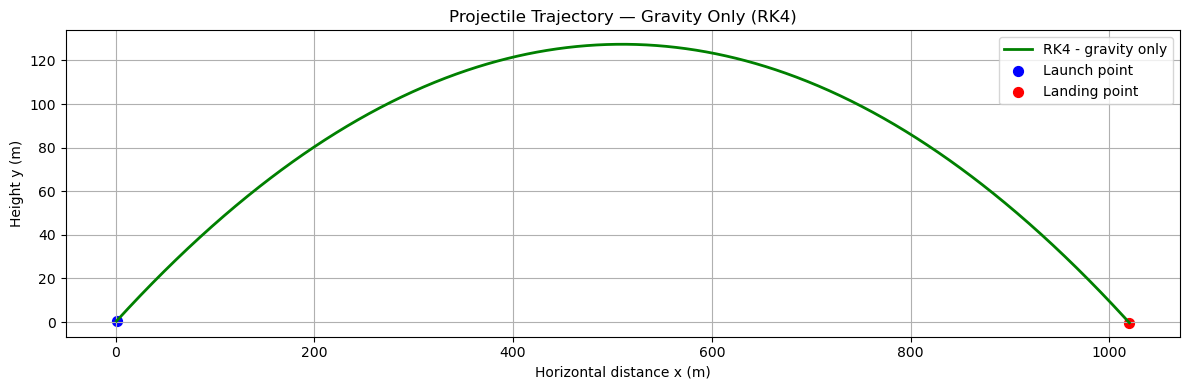

In [42]:
# Plot trajectory just for test:

plt.figure(figsize=(12, 4))

plt.plot(x, y, color="green",linewidth = 2, label="RK4 - gravity only")

plt.xlabel("Horizontal distance x (m)")
plt.ylabel("Height y (m)")

plt.title("Projectile Trajectory — Gravity Only (RK4)")

plt.grid(True)

plt.scatter(x[0], y[0], color='blue', s=50, label="Launch point")
plt.scatter(x[-1], y[-1], color='red', s=50, label="Landing point")

plt.legend()
plt.tight_layout()
plt.show()


> **Note:** The axes are not scaled equally in this plot. The trajectory spans approximately 1020 m horizontally but only 127 m vertically. Equal scaling would compress the curve and reduce readability. A true-scale visualization is provided in Section 5.8.

#### 5.6 Ray Propagation Module

In [ ]:
#TODO

#### 5.7 Stability Analysis

In [ ]:
#TODO

#### 5.8 Visualization

In [ ]:
#TODO